# 🎵 **Spotify Music Analysis Project**
## 📌 Project Overview

This project analyzes Spotify trending songs using streaming statistics, rankings, and genres to identify music trends, song popularity patterns, and artist performance.

The analysis includes:

Data Understanding
Feature Engineering
Exploratory Data Analysis
Correlation Analysis
Song Classification
Machine Learning Regression
Visualization & Insights
# 🎯 Objective
To analyze Spotify trending songs based on streams and rankings
To identify top-performing songs and genres
To study relationships between rankings, streams, and chart performance
To classify songs based on popularity
To apply regression analysis for predicting streams
# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 📂 **Load** **Dataset**

In [ ]:
df = pd.read_excel("Spotify_dataset_with_genres.xlsx")

print(df.head())

   week  rank                                   uri  \
0     1     1  spotify:track:5MCbGWnNLLjoHpbDO3BOgi   
1     1     2  spotify:track:0eLtIxPRNJfsmehITZ1qaJ   
2     1     3  spotify:track:5ThyDv6aRVU8AH4vXQNldF   
3     1     4  spotify:track:5xKr4HfdnYLMDmAJZkOuBc   
4     1     5  spotify:track:08GYLNhKthS3arMdXsveRI   

                                        artist_names  \
0  Shashwat Sachdev, Arijit Singh, Irshad Kamil, ...   
1                                     Aditya Rikhari   
2                         Kushagra, Bharath, Saaheal   
3  Shashwat Sachdev, Hanumankind, Jasmine Sandlas...   
4                      Talwiinder, NDS, Rippy Grewal   

                 track_name              source  peak_rank  previous_rank  \
0                 Gehra Hua  Saregama India Ltd          1              1   
1                    Sahiba            T-Series          1              2   
2               Finding Her       EYP Creations          1              5   
3  Dhurandhar - Title Tr

# **🧹 Data Understanding**

The dataset contains Spotify trending songs with ranking details, streams, artists, and genres.

Each row represents a song entry in Spotify charts.

In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   week            2200 non-null   int64 
 1   rank            2200 non-null   int64 
 2   uri             2200 non-null   object
 3   artist_names    2200 non-null   object
 4   track_name      2200 non-null   object
 5   source          2200 non-null   object
 6   peak_rank       2200 non-null   int64 
 7   previous_rank   2200 non-null   int64 
 8   weeks_on_chart  2200 non-null   int64 
 9   streams         2200 non-null   int64 
 10  genre           2200 non-null   object
dtypes: int64(6), object(5)
memory usage: 189.2+ KB
None
              week         rank    peak_rank  previous_rank  weeks_on_chart  \
count  2200.000000  2200.000000  2200.000000    2200.000000     2200.000000   
mean      6.000000   100.500000    39.443636      88.691364       78.996818   
std       3.162997    57.74

# **🔍 Check Missing Values**

In [ ]:
print(df.isnull().sum())

week              0
rank              0
uri               0
artist_names      0
track_name        0
source            0
peak_rank         0
previous_rank     0
weeks_on_chart    0
streams           0
genre             0
dtype: int64


# **🧠 Feature Engineering**

To improve analysis, new features are created:

Popularity Score = Streams ÷ Rank
Stability Score = Weeks on Chart × Streams
Rank Improvement = Previous Rank - Current Rank

These features help identify stable and trending songs.

In [ ]:
# Create new features

df['Popularity Score'] = df['streams'] / df['rank']

df['Stability Score'] = df['weeks_on_chart'] * df['streams']

df['Rank Improvement'] = df['previous_rank'] - df['rank']

# **📊 Top 10 Most Streamed Songs**

This analysis identifies the most streamed songs on Spotify.

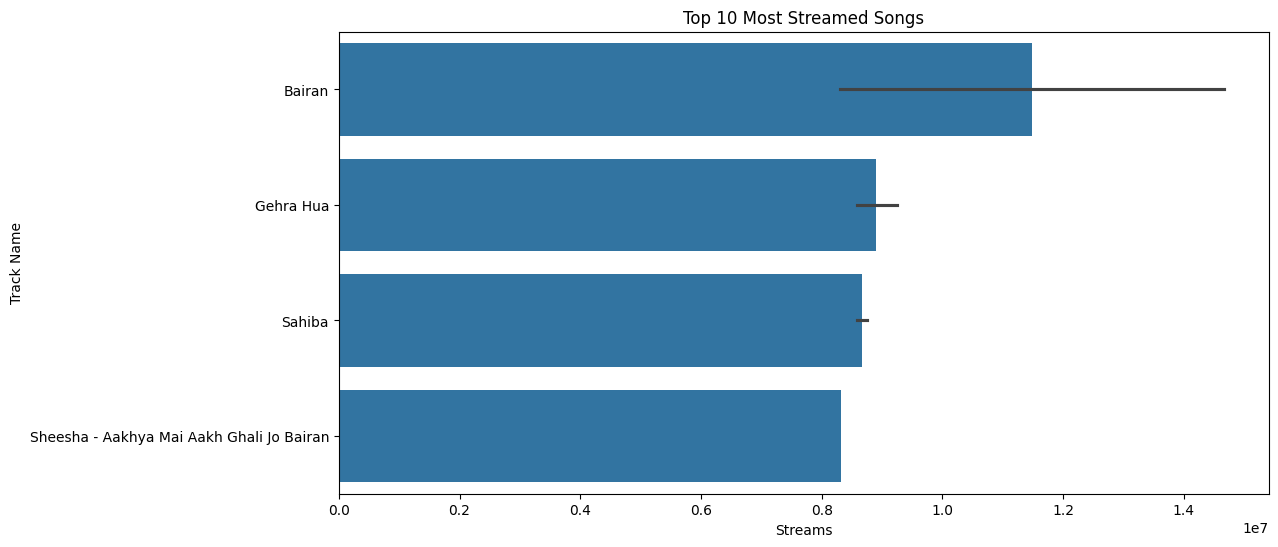

In [ ]:
plt.figure(figsize=(12,6))

top_streams = df.sort_values(by='streams', ascending=False).head(10)

sns.barplot(x='streams', y='track_name', data=top_streams)

plt.title("Top 10 Most Streamed Songs")
plt.xlabel("Streams")
plt.ylabel("Track Name")
plt.show()

**Insight**

Songs with extremely high streams dominate listener attention and represent major music trends.

# **🎤 Top Artists by Total Streams**

This analysis identifies artists generating the highest total streams.

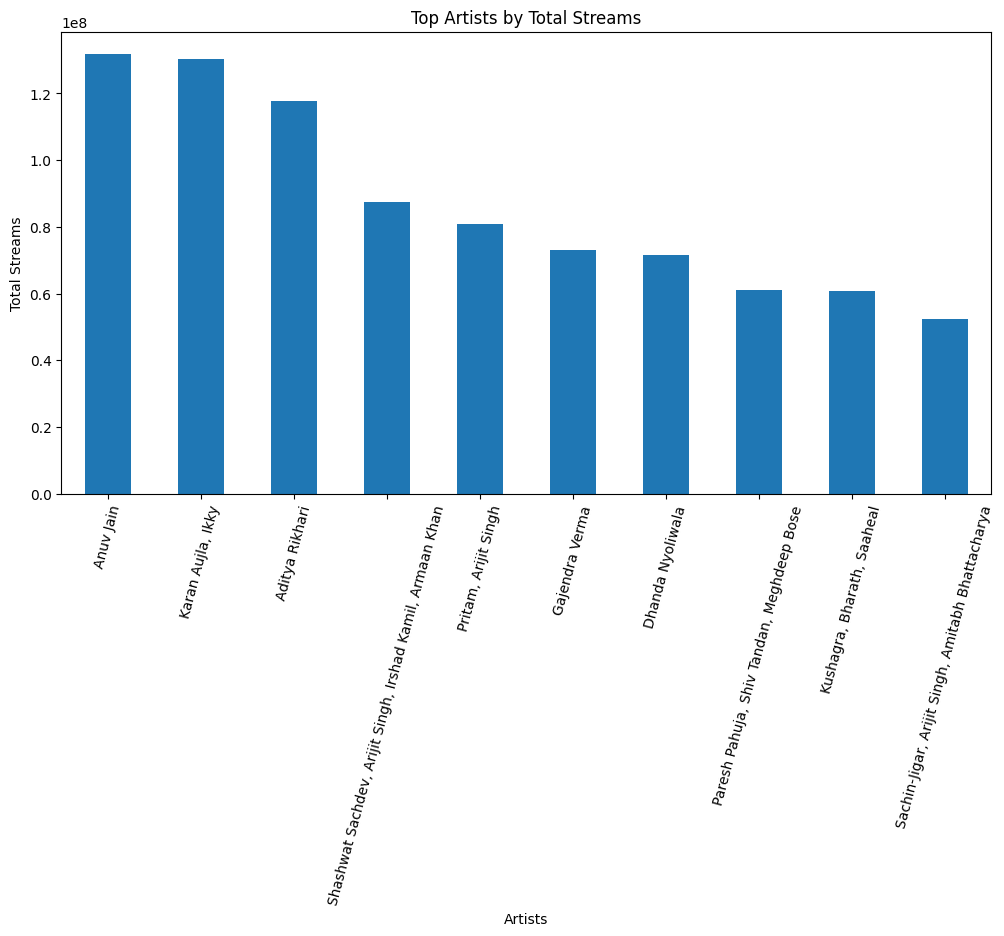

In [ ]:
artist_streams = df.groupby('artist_names')['streams'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
artist_streams.plot(kind='bar')

plt.title("Top Artists by Total Streams")
plt.xlabel("Artists")
plt.ylabel("Total Streams")
plt.xticks(rotation=75)
plt.show()

**Insight**

Top artists consistently attract listeners and dominate Spotify charts.

# **🎼 Most Popular Genres**

This analysis identifies the most streamed music genres.

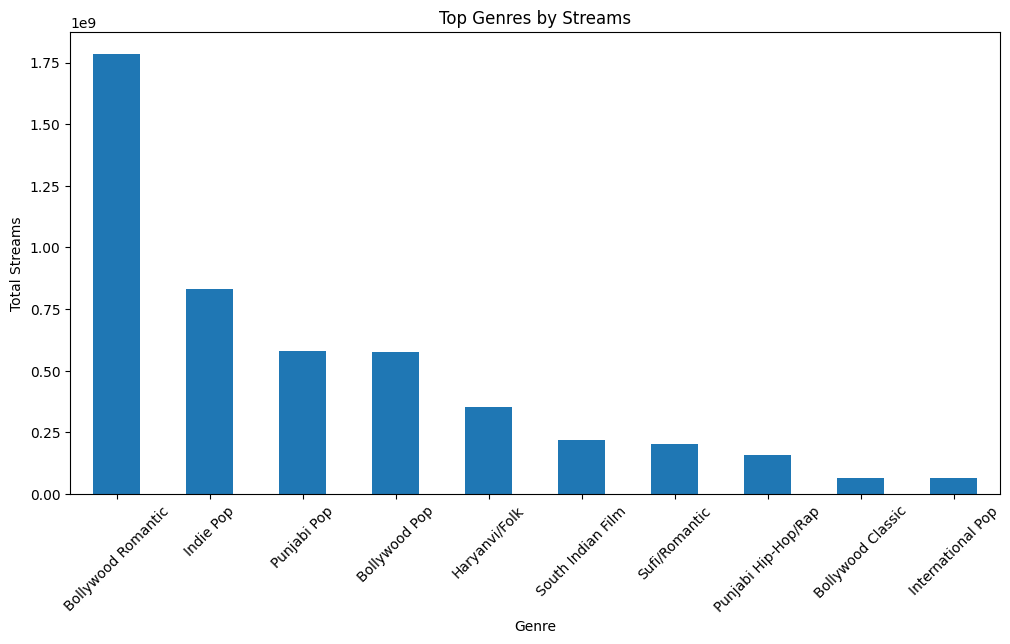

In [ ]:
plt.figure(figsize=(12,6))

genre_streams = df.groupby('genre')['streams'].sum().sort_values(ascending=False).head(10)

genre_streams.plot(kind='bar')

plt.title("Top Genres by Streams")
plt.xlabel("Genre")
plt.ylabel("Total Streams")
plt.xticks(rotation=45)
plt.show()

**Insight**

Certain genres attract significantly more audience engagement than others.

# **📈 Streams vs Weeks on Chart**

This analysis studies whether songs staying longer on charts receive higher streams.

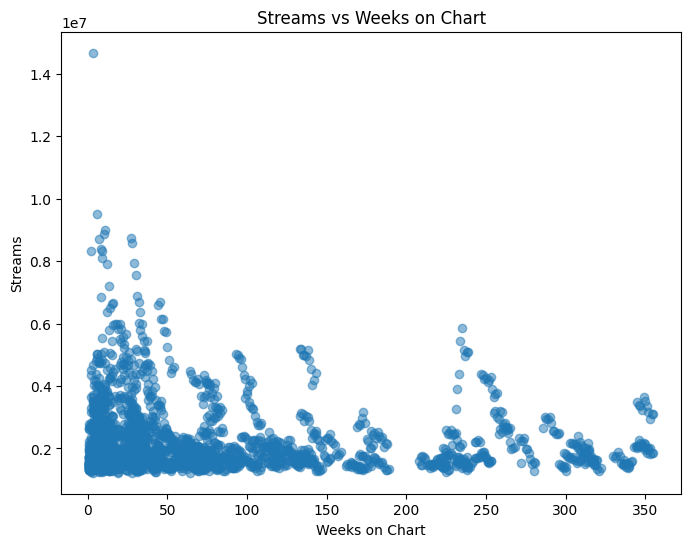

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(df['weeks_on_chart'], df['streams'], alpha=0.5)

plt.xlabel("Weeks on Chart")
plt.ylabel("Streams")
plt.title("Streams vs Weeks on Chart")
plt.show()

**Insight**

Songs with longer chart presence generally accumulate higher streams.

# **🔥 Rank vs Streams Relationship**

This analysis examines how song ranking affects streams.

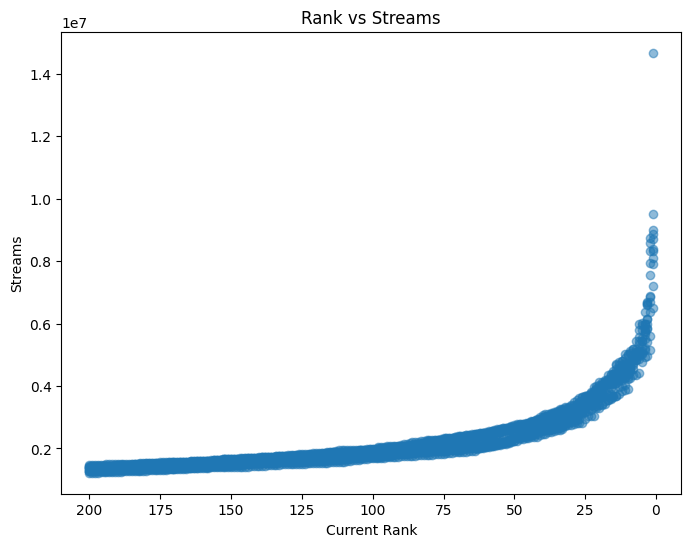

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(df['rank'], df['streams'], alpha=0.5)

plt.xlabel("Current Rank")
plt.ylabel("Streams")
plt.title("Rank vs Streams")
plt.gca().invert_xaxis()
plt.show()

**Insight**

Higher-ranked songs usually receive more streams.

# **📊 Correlation Analysis**

Correlation helps identify relationships between numerical features.

In [ ]:
cols = ['rank', 'peak_rank', 'previous_rank',
        'weeks_on_chart', 'streams',
        'Popularity Score', 'Stability Score',
        'Rank Improvement']

corr_matrix = df[cols].corr(numeric_only=True)

print(corr_matrix)

                      rank  peak_rank  previous_rank  weeks_on_chart  \
rank              1.000000   0.482974       0.704076        0.066482   
peak_rank         0.482974   1.000000       0.270069       -0.282389   
previous_rank     0.704076   0.270069       1.000000        0.110575   
weeks_on_chart    0.066482  -0.282389       0.110575        1.000000   
streams          -0.786180  -0.396240      -0.620689       -0.111915   
Popularity Score -0.289499  -0.152676      -0.242521       -0.083838   
Stability Score  -0.201730  -0.323726      -0.115929        0.890760   
Rank Improvement -0.373593  -0.271848       0.395668        0.058458   

                   streams  Popularity Score  Stability Score  \
rank             -0.786180         -0.289499        -0.201730   
peak_rank        -0.396240         -0.152676        -0.323726   
previous_rank    -0.620689         -0.242521        -0.115929   
weeks_on_chart   -0.111915         -0.083838         0.890760   
streams           1.000000

# **🌡️ Correlation Heatmap**

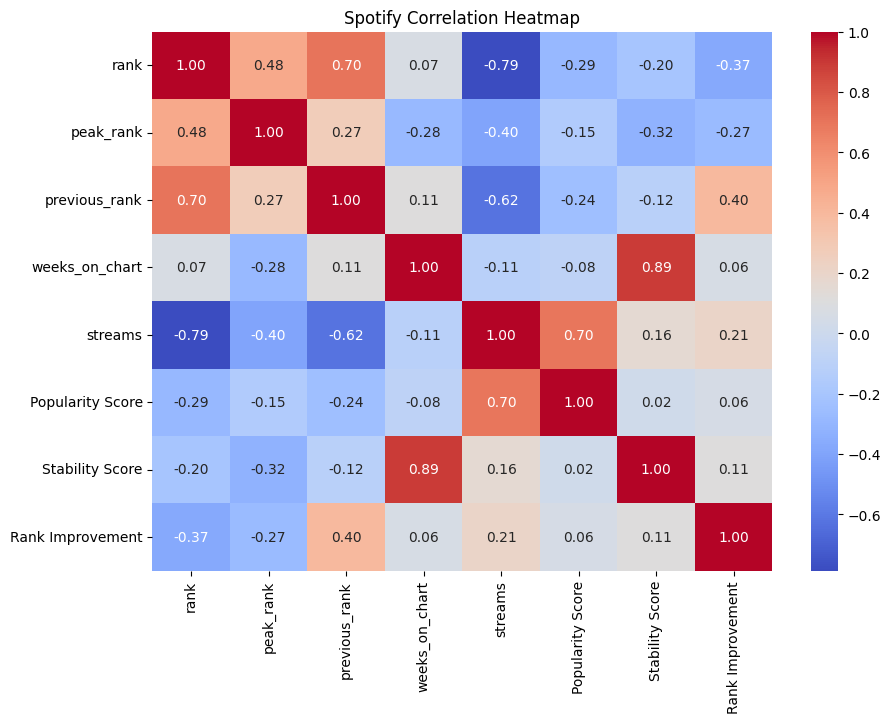

In [ ]:
plt.figure(figsize=(10,7))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Spotify Correlation Heatmap")
plt.show()

**Insight**

Strong positive and negative correlations reveal important relationships between ranking performance and streaming success.

# **🧩 Song Classification**

Songs are classified based on chart stability.

In [ ]:
# Classification Function

def song_type(row):
    if row['weeks_on_chart'] >= 30:
        return "Evergreen Hit"
    elif row['weeks_on_chart'] >= 15:
        return "Trending Song"
    else:
        return "New Viral Song"

# Apply Classification

df['Song Type'] = df.apply(song_type, axis=1)

print(df[['track_name', 'Song Type']].head())

                 track_name       Song Type
0                 Gehra Hua  New Viral Song
1                    Sahiba   Trending Song
2               Finding Her   Evergreen Hit
3  Dhurandhar - Title Track  New Viral Song
4                    Haseen   Evergreen Hit


# **📉 Song Type Distribution**

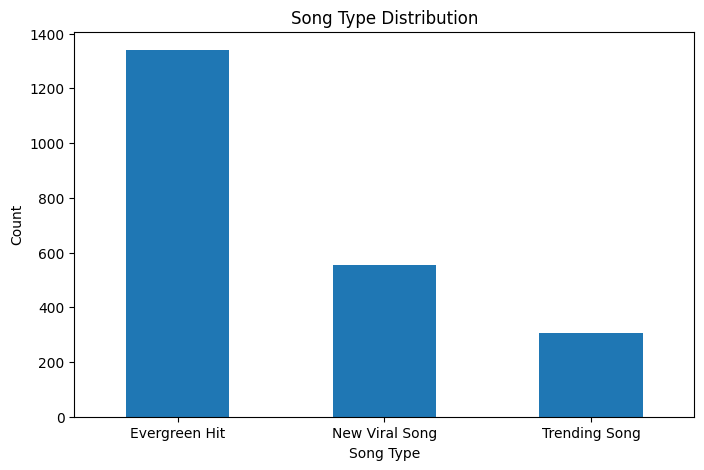

In [ ]:
plt.figure(figsize=(8,5))

df['Song Type'].value_counts().plot(kind='bar')

plt.title("Song Type Distribution")
plt.xlabel("Song Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

**Insight**

The dataset contains a mixture of viral tracks, trending songs, and evergreen hits.

# **🏆 Top Stable Songs**

This analysis identifies songs that remained on charts for the longest duration.

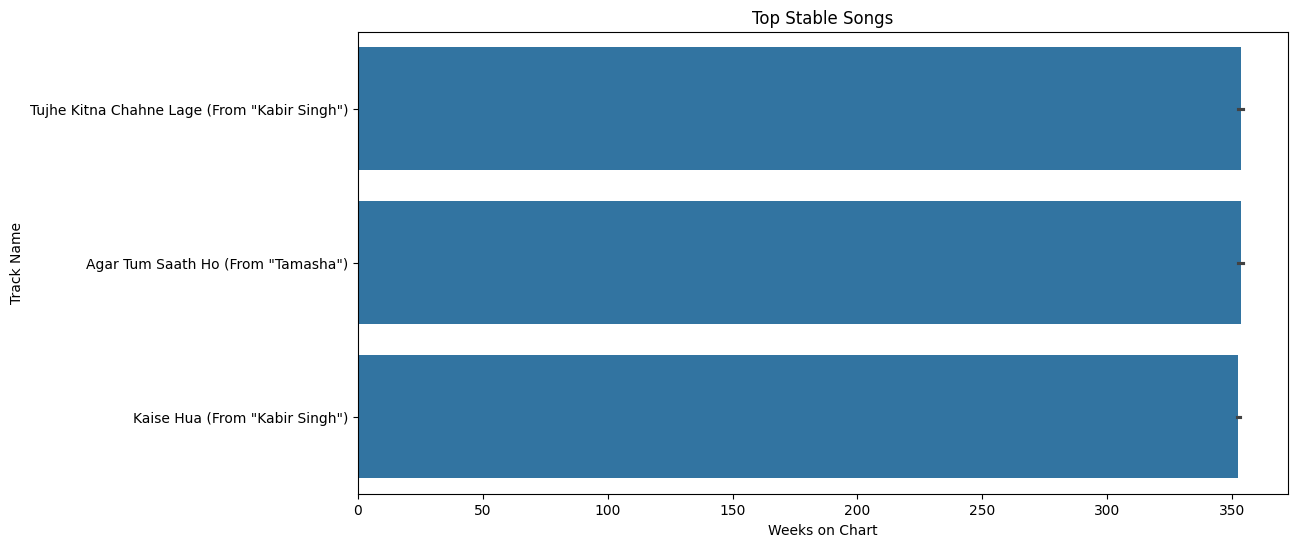

In [ ]:
stable_songs = df.sort_values(by='weeks_on_chart', ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(x='weeks_on_chart', y='track_name', data=stable_songs)

plt.title("Top Stable Songs")
plt.xlabel("Weeks on Chart")
plt.ylabel("Track Name")
plt.show()

**Insight**

Songs with long chart presence indicate consistent audience engagement.

# **🤖 Regression Analysis**

Linear Regression is used to predict streams using chart metrics.

In [ ]:
X = df[['rank', 'peak_rank', 'weeks_on_chart', 'Popularity Score']]

y = df['streams']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# **📌 Model Parameters**

In [ ]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 3424893.4820884936
Coefficients: [-1.22360130e+04 -6.26828933e+02 -4.07960142e+02  8.08031537e-01]


# **📊 Actual vs Predicted Streams**

In [ ]:
comparison = pd.DataFrame({
    'Actual Streams': y_test.values,
    'Predicted Streams': y_pred
})

print(comparison.head(20))

    Actual Streams  Predicted Streams
0          2251777       2.731125e+06
1          1618064       1.692737e+06
2          1373374       1.425042e+06
3          1457768       1.609438e+06
4          1367375       1.160337e+06
5          1809272       2.024951e+06
6          1299857       9.216176e+05
7          1749063       1.744417e+06
8          2619282       2.816556e+06
9          3761794       3.299708e+06
10         1535127       1.257553e+06
11         1902328       2.409877e+06
12         1770803       1.943537e+06
13         3948688       3.410654e+06
14         1919790       2.463714e+06
15         1676530       1.683547e+06
16         1422329       1.373716e+06
17         1498289       1.106323e+06
18         1510684       1.858042e+06
19         1936096       2.517026e+06


# **📈 Model Evaluation**

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 308031.0142578478
MSE: 164955639128.49133
R2 Score: 0.8571337504684505


**Insight**

A higher R² score indicates that the model effectively explains streaming behavior using ranking and chart features.

# **📉 Actual vs Predicted Visualization**

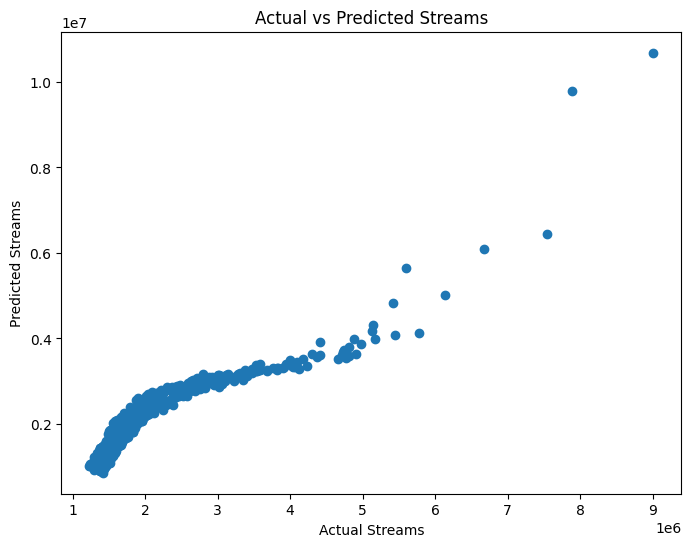

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Streams")
plt.ylabel("Predicted Streams")
plt.title("Actual vs Predicted Streams")
plt.show()

**Insight**

If points align closely to a straight line, the regression model performs accurately.

# **🏁 Conclusion**
Songs with better rankings generally receive more streams.

Longer chart presence strongly contributes to streaming success.

Popular genres dominate Spotify charts.

Stable songs maintain audience engagement for longer periods.

Regression analysis shows that ranking metrics significantly impact streams.

The project successfully demonstrates data analysis, visualization, feature engineering, and machine learning techniques using Spotify data.